# Code for STA 141C Final Project

## Data Exploration + Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

In [ ]:
heart_df = pd.read_csv("heart_disease_uci.csv")

heart_df["target_binary"] = (heart_df["num"] > 0).astype(int)

heart_df = heart_df.drop(columns=["num", "id"])

In [ ]:
rename_dict = {
    "age": "Age",
    "sex": "Sex",
    "cp": "Chest Pain Type",
    "trestbps": "Resting Blood Pressure",
    "chol": "Cholesterol",
    "fbs": "Fasting Blood Sugar",
    "restecg": "Resting ECG",
    "thalch": "Max Heart Rate",
    "exang": "Exercise-Induced Angina",
    "oldpeak": "ST Depression",
    "slope": "ST Slope",
    "ca": "Num Major Vessels",
    "thal": "Thalassemia",
    "target_binary": "Heart Disease"}

heart_df.rename(columns=rename_dict, inplace=True)

heart_df.head()

,Age,Sex,dataset,Chest Pain Type,Resting Blood Pressure,Cholesterol,Fasting Blood Sugar,Resting ECG,Max Heart Rate,Exercise-Induced Angina,ST Depression,ST Slope,Num Major Vessels,Thalassemia,Heart Disease
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
print("Shape:", heart_df.shape)

print("\nData Types:")

print(heart_df.dtypes)

print("\nMissing Values:")

print(heart_df.isnull().sum())

Shape: (920, 15)

Data Types:
Age                          int64
Sex                         object
dataset                     object
Chest Pain Type             object
Resting Blood Pressure     float64
Cholesterol                float64
Fasting Blood Sugar         object
Resting ECG                 object
Max Heart Rate             float64
Exercise-Induced Angina     object
ST Depression              float64
ST Slope                    object
Num Major Vessels          float64
Thalassemia                 object
Heart Disease                int64
dtype: object

Missing Values:
Age                          0
Sex                          0
dataset                      0
Chest Pain Type              0
Resting Blood Pressure      59
Cholesterol                 30
Fasting Blood Sugar         90
Resting ECG                  2
Max Heart Rate              55
Exercise-Induced Angina     55
ST Depression               62
ST Slope                   309
Num Major Vessels          611
Thalassemia

In [ ]:
missing_cols = heart_df.columns[heart_df.isnull().any()]

for col in missing_cols:
    print(f"\nMissing values in '{col}' by dataset:")
    print(heart_df[heart_df[col].isnull()]['dataset'].value_counts())


Missing values in 'Resting Blood Pressure' by dataset:
dataset
VA Long Beach    56
Switzerland       2
Hungary           1
Name: count, dtype: int64

Missing values in 'Cholesterol' by dataset:
dataset
Hungary          23
VA Long Beach     7
Name: count, dtype: int64

Missing values in 'Fasting Blood Sugar' by dataset:
dataset
Switzerland      75
Hungary           8
VA Long Beach     7
Name: count, dtype: int64

Missing values in 'Resting ECG' by dataset:
dataset
Hungary        1
Switzerland    1
Name: count, dtype: int64

Missing values in 'Max Heart Rate' by dataset:
dataset
VA Long Beach    53
Hungary           1
Switzerland       1
Name: count, dtype: int64

Missing values in 'Exercise-Induced Angina' by dataset:
dataset
VA Long Beach    53
Hungary           1
Switzerland       1
Name: count, dtype: int64

Missing values in 'ST Depression' by dataset:
dataset
VA Long Beach    56
Switzerland       6
Name: count, dtype: int64

Missing values in 'ST Slope' by dataset:
dataset
Hungary

In [ ]:
cleveland_df = heart_df[heart_df["dataset"] == "Cleveland"].copy()

cleveland_df = cleveland_df.drop(columns=["dataset"])

cleveland_df.isnull().sum()

,0
Age,0
Sex,0
Chest Pain Type,0
Resting Blood Pressure,0
Cholesterol,0
Fasting Blood Sugar,0
Resting ECG,0
Max Heart Rate,0
Exercise-Induced Angina,0
ST Depression,0


In [ ]:
cleveland_df = cleveland_df.dropna()

## Exploratory Data Analysis

In [ ]:
class_counts = cleveland_df["Heart Disease"].value_counts()
class_percent = cleveland_df["Heart Disease"].value_counts(normalize=True)

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percent)

Class Counts:
 Heart Disease
0    160
1    137
Name: count, dtype: int64

Class Percentages:
 Heart Disease
0    0.538721
1    0.461279
Name: proportion, dtype: float64


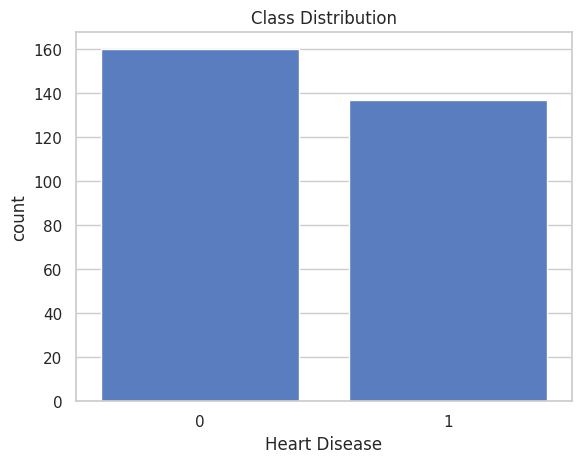

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

sns.countplot(x="Heart Disease", data=cleveland_df)
plt.title("Class Distribution")
plt.show()

In [ ]:
continuous_features = [
    "Age",
    "Resting Blood Pressure",
    "Cholesterol",
    "Max Heart Rate",
    "ST Depression"]

categorical_features = [
    "Sex",
    "Chest Pain Type",
    "Fasting Blood Sugar",
    "Resting ECG",
    "Exercise-Induced Angina",
    "ST Slope",
    "Num Major Vessels",
    "Thalassemia"]

print(cleveland_df[continuous_features].describe())

              Age  Resting Blood Pressure  Cholesterol  Max Heart Rate  \
count  297.000000              297.000000   297.000000      297.000000   
mean    54.542088              131.693603   247.350168      149.599327   
std      9.049736               17.762806    51.997583       22.941562   
min     29.000000               94.000000   126.000000       71.000000   
25%     48.000000              120.000000   211.000000      133.000000   
50%     56.000000              130.000000   243.000000      153.000000   
75%     61.000000              140.000000   276.000000      166.000000   
max     77.000000              200.000000   564.000000      202.000000   

       ST Depression  
count     297.000000  
mean        1.055556  
std         1.166123  
min         0.000000  
25%         0.000000  
50%         0.800000  
75%         1.600000  
max         6.200000  


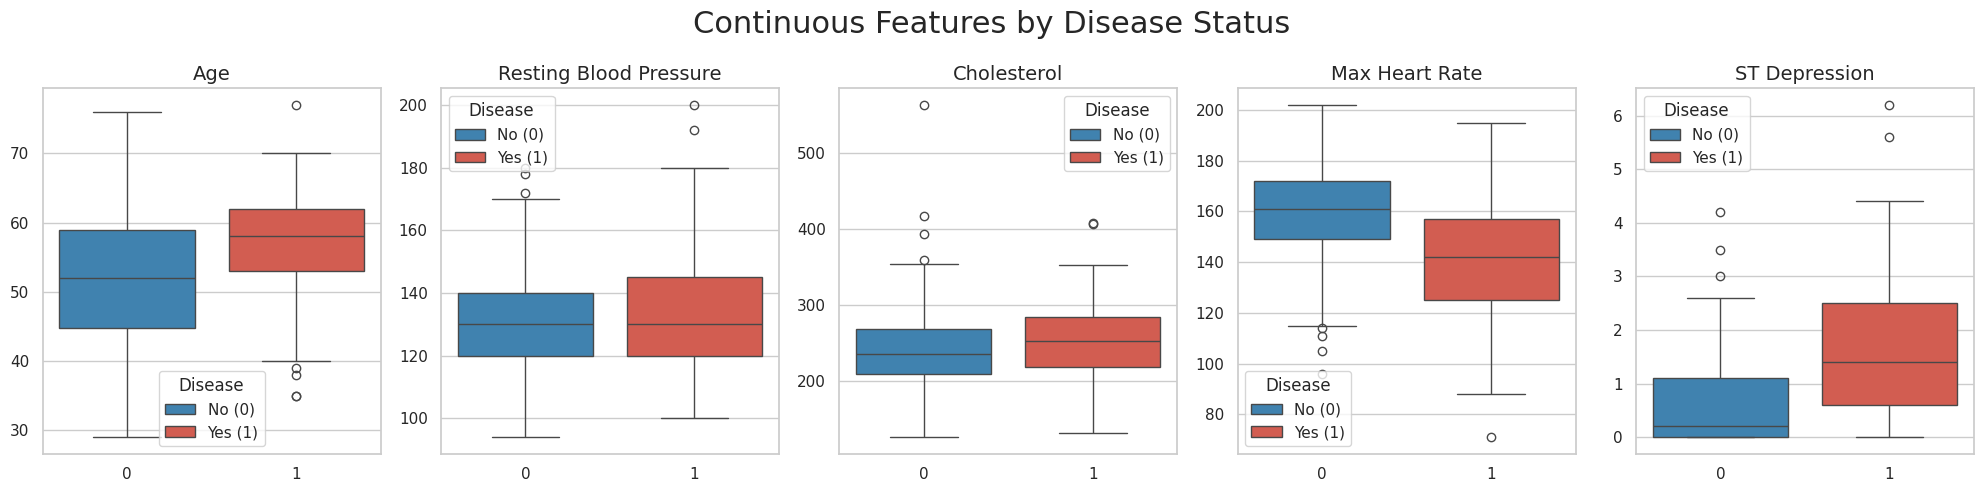

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.boxplot(
        x="Heart Disease",
        y=col,
        data=cleveland_df,
        hue="Heart Disease",
        ax=axes[i],
        palette=["#2E86C1", "#E74C3C"]
        )

    axes[i].set_title(col, fontsize=14)
    axes[i].legend(title="Disease", labels=["No (0)", "Yes (1)"])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Continuous Features by Disease Status", fontsize=22)
plt.tight_layout()
plt.show()

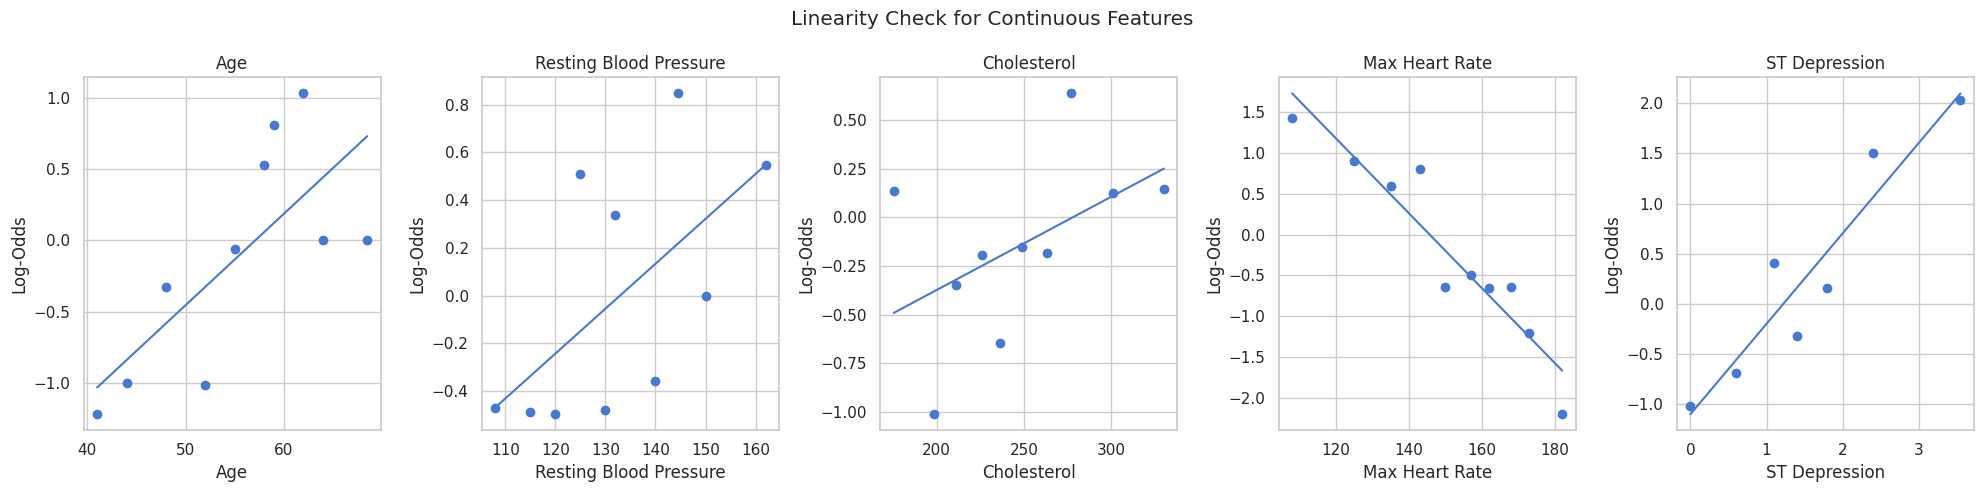

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes = axes.flatten()

for i, var in enumerate(continuous_features):

    temp = cleveland_df[[var, "Heart Disease"]].dropna().copy()
    temp["bin"] = pd.qcut(temp[var], q=10, duplicates="drop")

    grouped = temp.groupby("bin", observed=True)["Heart Disease"].mean()
    grouped = grouped[(grouped > 0) & (grouped < 1)]

    if len(grouped) < 3:
        continue

    log_odds = np.log(grouped / (1 - grouped))

    bin_medians = temp.groupby("bin", observed=True)[var].median()
    bin_medians = bin_medians.loc[log_odds.index]

    axes[i].scatter(bin_medians, log_odds)
    axes[i].set_title(var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Log-Odds")

    z = np.polyfit(bin_medians, log_odds, 1)
    p = np.poly1d(z)
    axes[i].plot(bin_medians, p(bin_medians))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Linearity Check for Continuous Features")
plt.tight_layout()
plt.show()

In [ ]:
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(cleveland_df[col].value_counts())


Value counts for Sex:
Sex
Male      201
Female     96
Name: count, dtype: int64

Value counts for Chest Pain Type:
Chest Pain Type
asymptomatic       142
non-anginal         83
atypical angina     49
typical angina      23
Name: count, dtype: int64

Value counts for Fasting Blood Sugar:
Fasting Blood Sugar
False    254
True      43
Name: count, dtype: int64

Value counts for Resting ECG:
Resting ECG
normal              147
lv hypertrophy      146
st-t abnormality      4
Name: count, dtype: int64

Value counts for Exercise-Induced Angina:
Exercise-Induced Angina
False    200
True      97
Name: count, dtype: int64

Value counts for ST Slope:
ST Slope
upsloping      139
flat           137
downsloping     21
Name: count, dtype: int64

Value counts for Num Major Vessels:
Num Major Vessels
0.0    174
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

Value counts for Thalassemia:
Thalassemia
normal               164
reversable defect    115
fixed defect          18
Name: count, dty

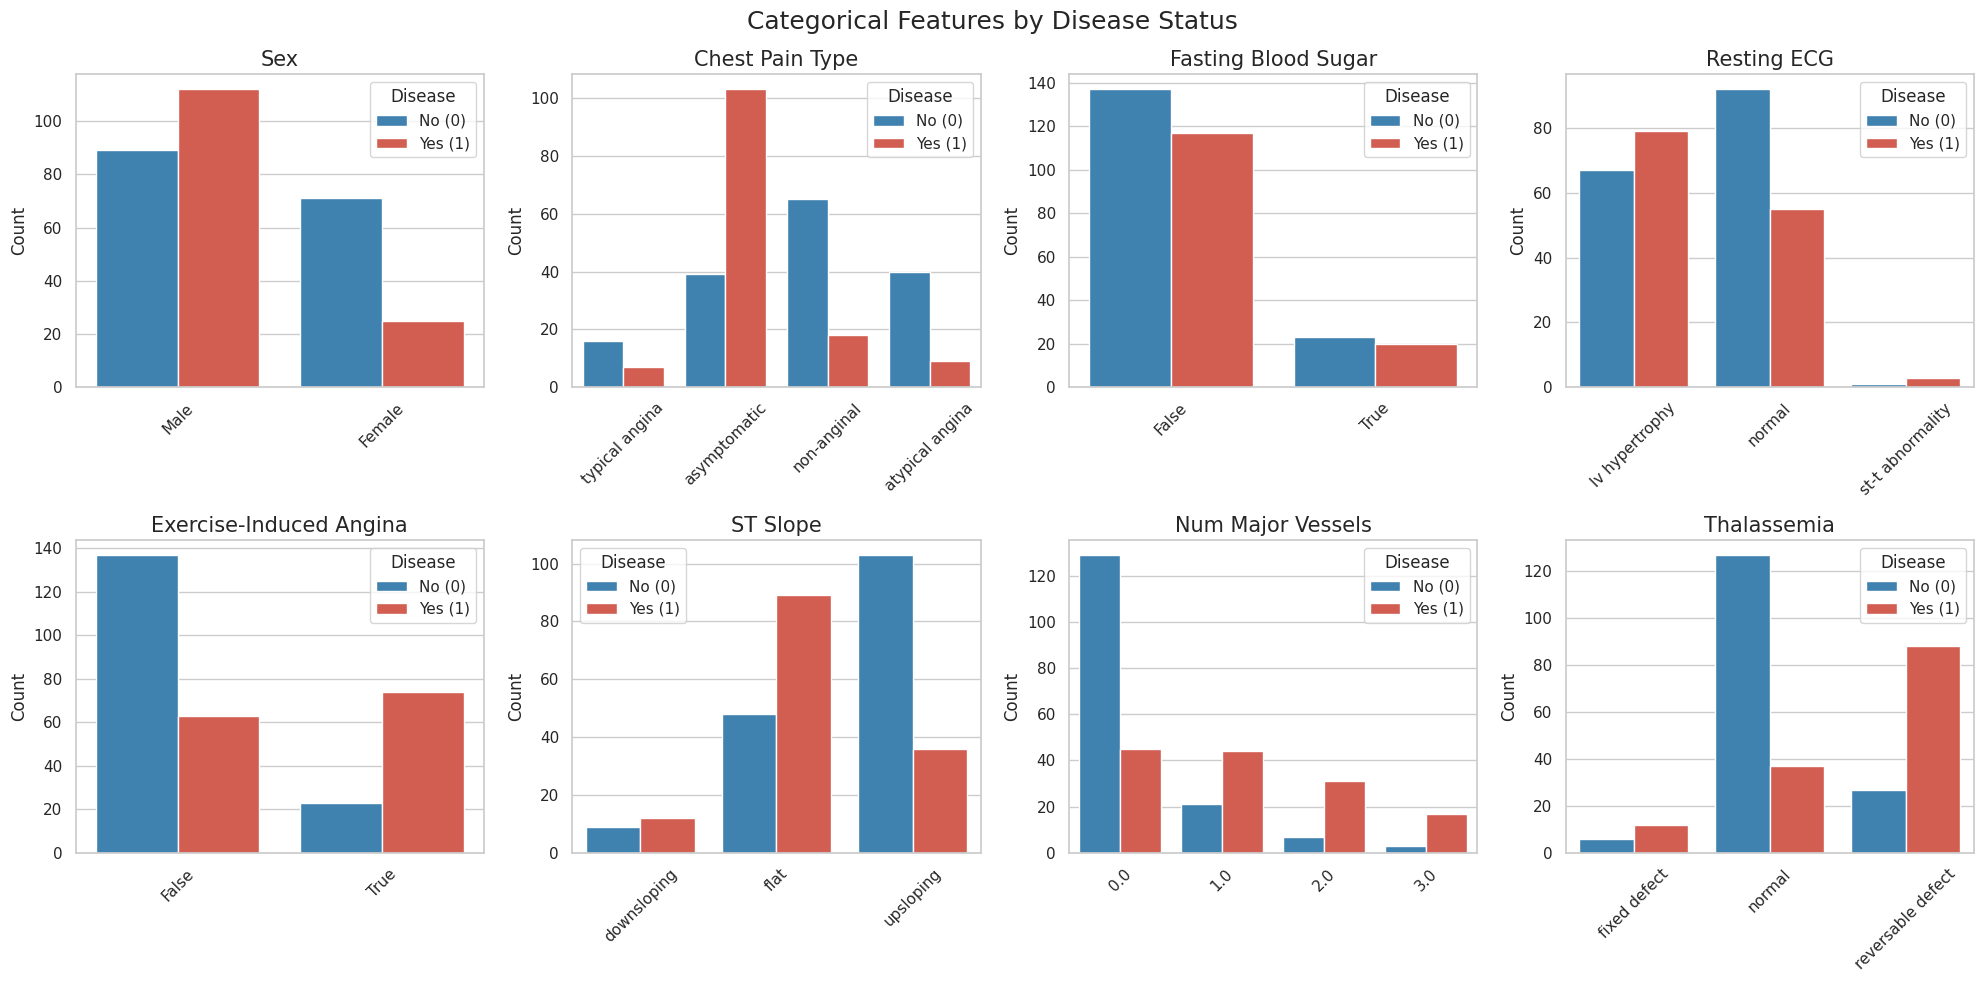

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        x=col,
        hue="Heart Disease",
        data=cleveland_df,
        ax=axes[i],
        palette=["#2E86C1", "#E74C3C"]
    )

    axes[i].set_title(col, fontsize=15)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Disease", labels=["No (0)", "Yes (1)"])
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Categorical Features by Disease Status", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
cleveland_df_num = pd.get_dummies(cleveland_df, drop_first=True)
cleveland_df_num = cleveland_df_num.astype(float)

print(cleveland_df_num.dtypes)

Age                                float64
Resting Blood Pressure             float64
Cholesterol                        float64
Max Heart Rate                     float64
ST Depression                      float64
Num Major Vessels                  float64
Heart Disease                      float64
Sex_Male                           float64
Chest Pain Type_atypical angina    float64
Chest Pain Type_non-anginal        float64
Chest Pain Type_typical angina     float64
Fasting Blood Sugar_True           float64
Resting ECG_normal                 float64
Resting ECG_st-t abnormality       float64
Exercise-Induced Angina_True       float64
ST Slope_flat                      float64
ST Slope_upsloping                 float64
Thalassemia_normal                 float64
Thalassemia_reversable defect      float64
dtype: object


In [ ]:
corr_with_target = cleveland_df[continuous_features].corrwith(cleveland_df["Heart Disease"])

print(corr_with_target)

Age                       0.227075
Resting Blood Pressure    0.153490
Cholesterol               0.080285
Max Heart Rate           -0.423817
ST Depression             0.424052
dtype: float64


In [ ]:
results = []

for var in categorical_features:
    temp = cleveland_df[[var, "Heart Disease"]].dropna()
    contingency = pd.crosstab(temp[var], temp["Heart Disease"])
    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    r, k = contingency.shape

    cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

    results.append((var, cramers_v, p))

cramers_table = pd.DataFrame(
    results,
    columns=["Variable", "Cramers_V", "p_value"])

cramers_table = cramers_table.sort_values(
    by="Cramers_V",
    ascending=False)

cramers_table

,Variable,Cramers_V,p_value
7,Thalassemia,0.526919,1.241673e-18
1,Chest Pain Type,0.510086,1.178284e-16
6,Num Major Vessels,0.493392,1.372578e-15
4,Exercise-Induced Angina,0.414154,9.510884e-13
5,ST Slope,0.382589,3.630107e-10
0,Sex,0.271246,2.945690e-06
3,Resting ECG,0.179557,8.331151e-03
2,Fasting Blood Sugar,0.000000,1.000000e+00


In [ ]:
X = cleveland_df.drop(columns=["Heart Disease"])
y = cleveland_df["Heart Disease"]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

print(X.dtypes)

Age                                float64
Resting Blood Pressure             float64
Cholesterol                        float64
Max Heart Rate                     float64
ST Depression                      float64
Num Major Vessels                  float64
Sex_Male                           float64
Chest Pain Type_atypical angina    float64
Chest Pain Type_non-anginal        float64
Chest Pain Type_typical angina     float64
Fasting Blood Sugar_True           float64
Resting ECG_normal                 float64
Resting ECG_st-t abnormality       float64
Exercise-Induced Angina_True       float64
ST Slope_flat                      float64
ST Slope_upsloping                 float64
Thalassemia_normal                 float64
Thalassemia_reversable defect      float64
dtype: object


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_vif = pd.DataFrame(X_scaled, columns=X.columns)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                            Feature       VIF
0                               Age  1.502780
1            Resting Blood Pressure  1.226644
2                       Cholesterol  1.150616
3                    Max Heart Rate  1.735684
4                     ST Depression  1.866709
5                 Num Major Vessels  1.377499
6                          Sex_Male  1.342241
7   Chest Pain Type_atypical angina  1.505768
8       Chest Pain Type_non-anginal  1.513534
9    Chest Pain Type_typical angina  1.242780
10         Fasting Blood Sugar_True  1.127052
11               Resting ECG_normal  1.121490
12     Resting ECG_st-t abnormality  1.076907
13     Exercise-Induced Angina_True  1.434947
14                    ST Slope_flat  4.840304
15               ST Slope_upsloping  5.907568
16               Thalassemia_normal  5.491236
17    Thalassemia_reversable defect  4.795685


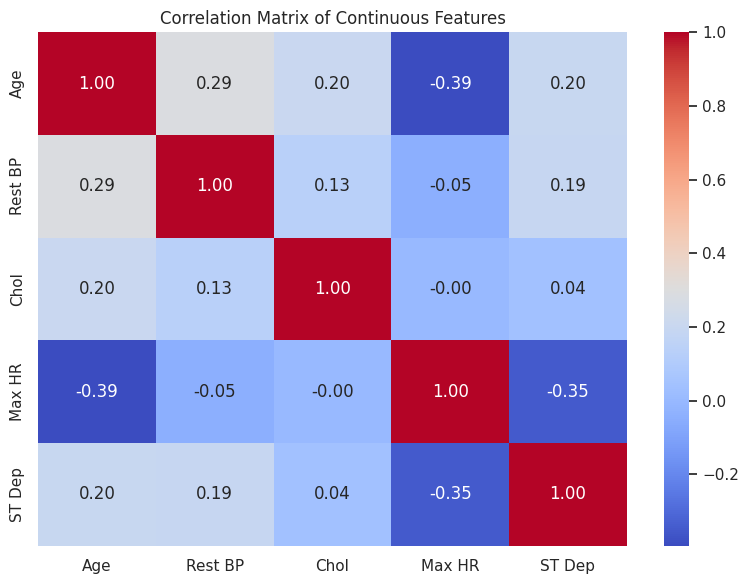

In [ ]:
short_labels = {
    "Age": "Age",
    "Resting Blood Pressure": "Rest BP",
    "Cholesterol": "Chol",
    "Max Heart Rate": "Max HR",
    "ST Depression": "ST Dep"}

corr = cleveland_df[continuous_features].corr()

corr.rename(index=short_labels, columns=short_labels, inplace=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Continuous Features")
plt.tight_layout()
plt.savefig("heart_disease_num_corr.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pd.DataFrame(X_scaled).to_csv("X_processed.csv", index=False)
pd.Series(y, name="target").to_csv("y_processed.csv", index=False)

print("Saved X_processed.csv and y_processed.csv")

Saved X_processed.csv and y_processed.csv


## Dimensionality Reduction with PCA

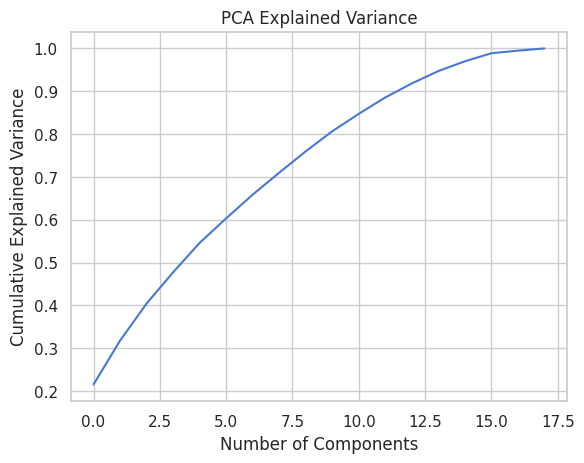

In [ ]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
thresholds = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

for t in thresholds:
    n_components = np.argmax(explained >= t) + 1
    print(f"{t*100:.0f}% variance explained by first {n_components} components")

25% variance explained by first 2 components
50% variance explained by first 5 components
75% variance explained by first 9 components
90% variance explained by first 13 components
95% variance explained by first 15 components
99% variance explained by first 17 components


In [ ]:
k_list = [2, 5, 9, 13, 15, 17]

explained_vars = []

for k in k_list:
    pca = PCA(n_components=k)
    pca.fit(X_scaled)
    var_explained = np.sum(pca.explained_variance_ratio_)

    explained_vars.append({
        "k": k,
        "Explained": var_explained * 100})

explained_var_df = pd.DataFrame(explained_vars)
print(explained_var_df)

    k  Explained
0   2  31.774093
1   5  54.600252
2   9  75.974140
3  13  91.835383
4  15  97.005456
5  17  99.490592


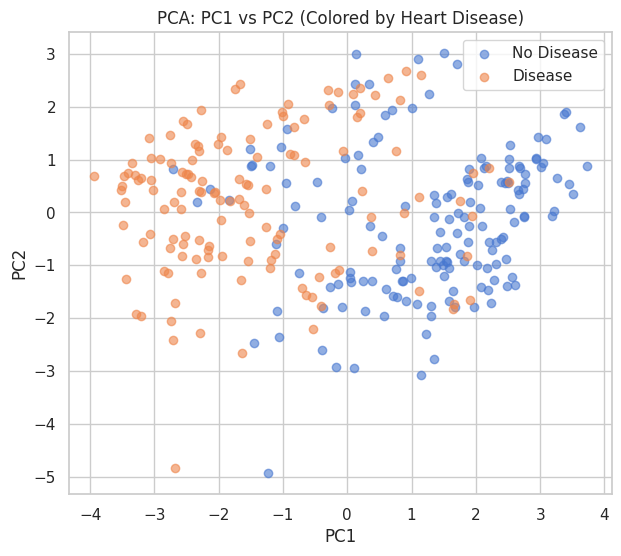

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca_2[y_arr == 0, 0],
    X_pca_2[y_arr == 0, 1],
    alpha=0.6,
    label="No Disease"
)

plt.scatter(
    X_pca_2[y_arr == 1, 0],
    X_pca_2[y_arr == 1, 1],
    alpha=0.6,
    label="Disease"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 (Colored by Heart Disease)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
feature_names = X.columns

loadings = pca_2.components_.T

loadings_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2"],
    index=feature_names
)

loadings_df["Abs_PC1"] = np.abs(loadings_df["PC1"])
loadings_df["Abs_PC2"] = np.abs(loadings_df["PC2"])

top_pc1 = loadings_df.sort_values("Abs_PC1", ascending=False).head(10)

top_pc2 = loadings_df.sort_values("Abs_PC2", ascending=False).head(10)

print("Top variables for PC1:")
display(top_pc1[["PC1", "Abs_PC1"]])

print("\nTop variables for PC2:")
display(top_pc2[["PC2", "Abs_PC2"]])

Top variables for PC1:


,PC1,Abs_PC1
ST Slope_upsloping,0.367391,0.367391
Thalassemia_normal,0.356518,0.356518
ST Depression,-0.337245,0.337245
Max Heart Rate,0.333317,0.333317
ST Slope_flat,-0.330619,0.330619
Thalassemia_reversable defect,-0.320223,0.320223
Exercise-Induced Angina_True,-0.279043,0.279043
Num Major Vessels,-0.239555,0.239555
Age,-0.217340,0.217340
Chest Pain Type_atypical angina,0.216176,0.216176



Top variables for PC2:


,PC2,Abs_PC2
Sex_Male,0.481341,0.481341
Thalassemia_reversable defect,0.405789,0.405789
Thalassemia_normal,-0.393628,0.393628
Age,-0.323754,0.323754
Cholesterol,-0.269659,0.269659
Resting ECG_normal,0.234248,0.234248
Resting ECG_st-t abnormality,-0.224122,0.224122
Resting Blood Pressure,-0.186903,0.186903
ST Slope_flat,-0.167940,0.167940
ST Slope_upsloping,0.167632,0.167632


## Logistic Regression Modeling

### Baseline Logistic Regression

In [ ]:
def cv_logistic_baseline(X_scaled, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_aucs, val_aucs = [], []
    train_accs, val_accs = [], []
    fit_times = []

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr), start=1):
        X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

        model = LogisticRegression(
            C=1e12,
            solver="lbfgs",
            max_iter=5000
        )

        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        t1 = time.perf_counter()

        p_tr = model.predict_proba(X_tr)[:, 1]
        yhat_tr = (p_tr >= 0.5).astype(int)

        train_auc = roc_auc_score(y_tr, p_tr)
        train_acc = accuracy_score(y_tr, yhat_tr)

        p_va = model.predict_proba(X_va)[:, 1]
        yhat_va = (p_va >= 0.5).astype(int)

        val_auc = roc_auc_score(y_va, p_va)
        val_acc = accuracy_score(y_va, yhat_va)

        train_aucs.append(train_auc)
        train_accs.append(train_acc)
        val_aucs.append(val_auc)
        val_accs.append(val_acc)
        fit_times.append(t1 - t0)

        print(
            f"Fold {fold}: "
            f"Train AUC={train_auc:.4f}, Train Acc={train_acc:.4f} | "
            f"Val AUC={val_auc:.4f}, Val Acc={val_acc:.4f} | "
            f"FitTime={t1-t0:.4f}s")

    print("\n=== 5-Fold CV Summary (Baseline Logistic) ===")
    print(f"Train AUC: {np.mean(train_aucs):.4f} ± {np.std(train_aucs, ddof=1):.4f}")
    print(f"Val AUC:   {np.mean(val_aucs):.4f} ± {np.std(val_aucs, ddof=1):.4f}")
    print(f"Train Acc: {np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}")
    print(f"Val Acc:   {np.mean(val_accs):.4f} ± {np.std(val_accs, ddof=1):.4f}")
    print(f"Fit time:  {np.mean(fit_times):.4f}s ± {np.std(fit_times, ddof=1):.4f}s")

    return {
        "Train_AUC_mean": float(np.mean(train_aucs)),
        "Train_AUC_std": float(np.std(train_aucs, ddof=1)),
        "Val_AUC_mean": float(np.mean(val_aucs)),
        "Val_AUC_std": float(np.std(val_aucs, ddof=1)),
        "Train_Acc_mean": float(np.mean(train_accs)),
        "Train_Acc_std": float(np.std(train_accs, ddof=1)),
        "Val_Acc_mean": float(np.mean(val_accs)),
        "Val_Acc_std": float(np.std(val_accs, ddof=1)),
        "FitTime_mean_sec": float(np.mean(fit_times)),
        "FitTime_std_sec": float(np.std(fit_times, ddof=1)),
        "Train_AUCs": train_aucs,
        "Val_AUCs": val_aucs,
        "Train_Accs": train_accs,
        "Val_Accs": val_accs,
        "FitTimes_sec": fit_times}

baseline_results = cv_logistic_baseline(X_scaled, y, n_splits=5, random_state=42)

Fold 1: Train AUC=0.9312, Train Acc=0.8734 | Val AUC=0.9386, Val Acc=0.9000 | FitTime=0.0043s
Fold 2: Train AUC=0.9404, Train Acc=0.8650 | Val AUC=0.8705, Val Acc=0.7833 | FitTime=0.0057s
Fold 3: Train AUC=0.9545, Train Acc=0.9034 | Val AUC=0.8322, Val Acc=0.7627 | FitTime=0.0042s
Fold 4: Train AUC=0.9423, Train Acc=0.8697 | Val AUC=0.8646, Val Acc=0.8305 | FitTime=0.0047s
Fold 5: Train AUC=0.9311, Train Acc=0.8655 | Val AUC=0.9375, Val Acc=0.8305 | FitTime=0.0041s

=== 5-Fold CV Summary (Baseline Logistic) ===
Train AUC: 0.9399 ± 0.0097
Val AUC:   0.8887 ± 0.0474
Train Acc: 0.8754 ± 0.0160
Val Acc:   0.8214 ± 0.0530
Fit time:  0.0046s ± 0.0007s


### Ridge

In [ ]:
def cv_ridge_logistic(X_scaled, y, C_values, n_splits=5, random_state=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    results = []

    for C in C_values:
        train_aucs, val_aucs = [], []
        train_accs, val_accs = [], []
        times = []

        for train_idx, val_idx in skf.split(X_scaled, y_arr):

            X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=5000
            )

            t0 = time.perf_counter()
            model.fit(X_tr, y_tr)
            t1 = time.perf_counter()

            p_tr = model.predict_proba(X_tr)[:, 1]
            yhat_tr = (p_tr >= 0.5).astype(int)

            train_auc = roc_auc_score(y_tr, p_tr)
            train_acc = accuracy_score(y_tr, yhat_tr)

            p_va = model.predict_proba(X_va)[:, 1]
            yhat_va = (p_va >= 0.5).astype(int)

            val_auc = roc_auc_score(y_va, p_va)
            val_acc = accuracy_score(y_va, yhat_va)

            train_aucs.append(train_auc)
            train_accs.append(train_acc)
            val_aucs.append(val_auc)
            val_accs.append(val_acc)
            times.append(t1 - t0)

        results.append({
            "C": C,
            "Train_AUC_mean": np.mean(train_aucs),
            "Train_AUC_std": np.std(train_aucs, ddof=1),
            "Val_AUC_mean": np.mean(val_aucs),
            "Val_AUC_std": np.std(val_aucs, ddof=1),
            "Train_Acc_mean": np.mean(train_accs),
            "Train_Acc_std": np.std(train_accs, ddof=1),
            "Val_Acc_mean": np.mean(val_accs),
            "Val_Acc_std": np.std(val_accs, ddof=1),
            "FitTime_mean": np.mean(times)})

        print(
            f"C={C}: "
            f"Train AUC={np.mean(train_aucs):.4f} ± {np.std(train_aucs, ddof=1):.4f}, "
            f"Val AUC={np.mean(val_aucs):.4f} ± {np.std(val_aucs, ddof=1):.4f}, "
            f"Train Acc={np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}, "
            f"Val Acc={np.mean(val_accs):.4f} ± {np.std(val_accs, ddof=1):.4f}, "
            f"FitTime={np.mean(times):.4f}s ± {np.std(times, ddof=1):.4f}s")

    return results


C_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_results = cv_ridge_logistic(X_scaled, y, C_grid)

C=0.001: Train AUC=0.9129 ± 0.0105, Val AUC=0.9058 ± 0.0406, Train Acc=0.7996 ± 0.0180, Val Acc=0.7945 ± 0.0425, FitTime=0.0274s ± 0.0025s
C=0.01: Train AUC=0.9215 ± 0.0102, Val AUC=0.9072 ± 0.0428, Train Acc=0.8535 ± 0.0193, Val Acc=0.8316 ± 0.0587, FitTime=0.0116s ± 0.0096s
C=0.1: Train AUC=0.9344 ± 0.0100, Val AUC=0.9014 ± 0.0489, Train Acc=0.8670 ± 0.0186, Val Acc=0.8416 ± 0.0667, FitTime=0.0181s ± 0.0140s
C=1: Train AUC=0.9397 ± 0.0098, Val AUC=0.8948 ± 0.0486, Train Acc=0.8712 ± 0.0143, Val Acc=0.8281 ± 0.0490, FitTime=0.0349s ± 0.0163s
C=10: Train AUC=0.9398 ± 0.0097, Val AUC=0.8927 ± 0.0465, Train Acc=0.8746 ± 0.0162, Val Acc=0.8247 ± 0.0505, FitTime=0.0156s ± 0.0200s
C=100: Train AUC=0.9399 ± 0.0096, Val AUC=0.8909 ± 0.0466, Train Acc=0.8754 ± 0.0160, Val Acc=0.8214 ± 0.0530, FitTime=0.0165s ± 0.0121s
C=1000: Train AUC=0.9399 ± 0.0097, Val AUC=0.8889 ± 0.0473, Train Acc=0.8754 ± 0.0160, Val Acc=0.8214 ± 0.0530, FitTime=0.0214s ± 0.0198s


### Lasso

In [ ]:
def cv_lasso_logistic(X_scaled, y, C_values, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    results = []

    for C in C_values:

        train_aucs, val_aucs = [], []
        train_accs, val_accs = [], []
        times, n_nonzero = [], []

        for train_idx, val_idx in skf.split(X_scaled, y_arr):

            X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                penalty="l1",
                C=C,
                solver="liblinear",
                max_iter=5000
            )

            t0 = time.perf_counter()
            model.fit(X_tr, y_tr)
            t1 = time.perf_counter()

            p_tr = model.predict_proba(X_tr)[:, 1]
            yhat_tr = (p_tr >= 0.5).astype(int)

            train_aucs.append(roc_auc_score(y_tr, p_tr))
            train_accs.append(accuracy_score(y_tr, yhat_tr))

            p_va = model.predict_proba(X_va)[:, 1]
            yhat_va = (p_va >= 0.5).astype(int)

            val_aucs.append(roc_auc_score(y_va, p_va))
            val_accs.append(accuracy_score(y_va, yhat_va))

            times.append(t1 - t0)
            n_nonzero.append(np.sum(model.coef_ != 0))

        results.append({
            "C": C,
            "Train_AUC_mean": np.mean(train_aucs),
            "Train_AUC_std": np.std(train_aucs, ddof=1),
            "Val_AUC_mean": np.mean(val_aucs),
            "Val_AUC_std": np.std(val_aucs, ddof=1),
            "Train_Acc_mean": np.mean(train_accs),
            "Train_Acc_std": np.std(train_accs, ddof=1),
            "Val_Acc_mean": np.mean(val_accs),
            "Val_Acc_std": np.std(val_accs, ddof=1),
            "FitTime_mean": np.mean(times),
            "FitTime_std": np.std(times, ddof=1),
            "Num_Selected_mean": np.mean(n_nonzero)})

        print(
            f"C={C}: "
            f"Train AUC={np.mean(train_aucs):.4f} ± {np.std(train_aucs, ddof=1):.4f}, "
            f"Val AUC={np.mean(val_aucs):.4f} ± {np.std(val_aucs, ddof=1):.4f}, "
            f"Train Acc={np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}, "
            f"Val Acc={np.mean(val_accs):.4f} ± {np.std(val_accs, ddof=1):.4f}, "
            f"Selected Features={np.mean(n_nonzero):.1f}, "
            f"FitTime={np.mean(times):.4f}s ± {np.std(times, ddof=1):.4f}s"
        )

    return results


C_grid_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

lasso_results = cv_lasso_logistic(X_scaled, y, C_grid_lasso)

C=0.001: Train AUC=0.5000 ± 0.0000, Val AUC=0.5000 ± 0.0000, Train Acc=0.4613 ± 0.0012, Val Acc=0.4612 ± 0.0050, Selected Features=0.0, FitTime=0.0066s ± 0.0011s
C=0.01: Train AUC=0.5000 ± 0.0000, Val AUC=0.5000 ± 0.0000, Train Acc=0.4613 ± 0.0012, Val Acc=0.4612 ± 0.0050, Selected Features=0.0, FitTime=0.0040s ± 0.0010s
C=0.05: Train AUC=0.9077 ± 0.0126, Val AUC=0.8909 ± 0.0437, Train Acc=0.8400 ± 0.0227, Val Acc=0.8115 ± 0.0480, Selected Features=8.0, FitTime=0.0056s ± 0.0020s
C=0.1: Train AUC=0.9203 ± 0.0116, Val AUC=0.8947 ± 0.0504, Train Acc=0.8535 ± 0.0211, Val Acc=0.8079 ± 0.0587, Selected Features=11.6, FitTime=0.0046s ± 0.0025s
C=0.5: Train AUC=0.9378 ± 0.0099, Val AUC=0.8968 ± 0.0461, Train Acc=0.8661 ± 0.0158, Val Acc=0.8214 ± 0.0632, Selected Features=15.4, FitTime=0.0029s ± 0.0007s
C=1: Train AUC=0.9393 ± 0.0096, Val AUC=0.8963 ± 0.0464, Train Acc=0.8704 ± 0.0169, Val Acc=0.8214 ± 0.0632, Selected Features=16.8, FitTime=0.0064s ± 0.0044s
C=5: Train AUC=0.9399 ± 0.0098, Val

In [ ]:
best_C = 0.5

best_lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=best_C,
    max_iter=5000
)

best_lasso.fit(X_scaled, y)

feature_names = X.columns

coef = best_lasso.coef_[0]

lasso_features = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

lasso_selected = lasso_features[lasso_features["Coefficient"] != 0]

lasso_selected = lasso_selected.reindex(
    lasso_selected["Coefficient"].abs().sort_values(ascending=False).index
)

print("Selected Features by Lasso:\n")
print(lasso_selected)

print("\nNumber of selected features:", len(lasso_selected))

Selected Features by Lasso:

                            Feature  Coefficient
5                 Num Major Vessels     1.014603
8       Chest Pain Type_non-anginal    -0.679113
17    Thalassemia_reversable defect     0.589834
6                          Sex_Male     0.535031
9    Chest Pain Type_typical angina    -0.433767
4                     ST Depression     0.389332
13     Exercise-Induced Angina_True     0.315324
3                    Max Heart Rate    -0.314726
1            Resting Blood Pressure     0.284936
14                    ST Slope_flat     0.265204
7   Chest Pain Type_atypical angina    -0.247905
15               ST Slope_upsloping    -0.191321
11               Resting ECG_normal    -0.184241
2                       Cholesterol     0.114319
10         Fasting Blood Sugar_True    -0.109369
16               Thalassemia_normal    -0.060772

Number of selected features: 16


### Logistic Regression on PCA-Reduced Data

In [ ]:
def cv_logistic_pca(X_scaled, y, n_components, n_splits=5, random_state=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_aucs, val_aucs = [], []
    train_accs, val_accs = [], []
    fit_times = []

    y_arr = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_arr), start=1):

        X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

        pca = PCA(n_components=n_components)
        X_tr_pca = pca.fit_transform(X_tr)
        X_va_pca = pca.transform(X_va)

        model = LogisticRegression(
            C=1e12,
            solver="lbfgs",
            max_iter=5000
        )

        t0 = time.perf_counter()
        model.fit(X_tr_pca, y_tr)
        t1 = time.perf_counter()

        p_tr = model.predict_proba(X_tr_pca)[:, 1]
        yhat_tr = (p_tr >= 0.5).astype(int)

        train_auc = roc_auc_score(y_tr, p_tr)
        train_acc = accuracy_score(y_tr, yhat_tr)

        p_va = model.predict_proba(X_va_pca)[:, 1]
        yhat_va = (p_va >= 0.5).astype(int)

        val_auc = roc_auc_score(y_va, p_va)
        val_acc = accuracy_score(y_va, yhat_va)

        train_aucs.append(train_auc)
        train_accs.append(train_acc)
        val_aucs.append(val_auc)
        val_accs.append(val_acc)
        fit_times.append(t1 - t0)

        print(
            f"Fold {fold}: "
            f"Train AUC={train_auc:.4f}, Train Acc={train_acc:.4f} | "
            f"Val AUC={val_auc:.4f}, Val Acc={val_acc:.4f} | "
            f"FitTime={t1-t0:.4f}s"
        )

    print("\n=== 5-Fold CV Summary (PCA Logistic) ===")
    print(f"Train AUC: {np.mean(train_aucs):.4f} ± {np.std(train_aucs, ddof=1):.4f}")
    print(f"Val AUC:   {np.mean(val_aucs):.4f} ± {np.std(val_aucs, ddof=1):.4f}")
    print(f"Train Acc: {np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}")
    print(f"Val Acc:   {np.mean(val_accs):.4f} ± {np.std(val_accs, ddof=1):.4f}")
    print(f"Fit time:  {np.mean(fit_times):.4f}s ± {np.std(fit_times, ddof=1):.4f}s")

    return {
        "Train_AUC_mean": np.mean(train_aucs),
        "Val_AUC_mean": np.mean(val_aucs),
        "Train_Acc_mean": np.mean(train_accs),
        "Val_Acc_mean": np.mean(val_accs),
        "FitTime_mean_sec": np.mean(fit_times)
    }

In [ ]:
components_to_try = [2, 5, 9, 13, 15, 17]
results_pca = []

for n_components in components_to_try:

    print(f"\n=== Running CV with {n_components} PCA components ===")

    res = cv_logistic_pca(X_scaled, y, n_components)

    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    explained_var = np.sum(pca.explained_variance_ratio_)

    res["n_components"] = n_components
    res["explained_variance"] = explained_var

    results_pca.append(res)


=== Running CV with 2 PCA components ===
Fold 1: Train AUC=0.8884, Train Acc=0.8101 | Val AUC=0.9208, Val Acc=0.8167 | FitTime=0.0278s
Fold 2: Train AUC=0.8973, Train Acc=0.8270 | Val AUC=0.8873, Val Acc=0.7500 | FitTime=0.0049s
Fold 3: Train AUC=0.9184, Train Acc=0.8319 | Val AUC=0.8391, Val Acc=0.7288 | FitTime=0.0033s
Fold 4: Train AUC=0.8967, Train Acc=0.8109 | Val AUC=0.8970, Val Acc=0.8305 | FitTime=0.0033s
Fold 5: Train AUC=0.8853, Train Acc=0.8025 | Val AUC=0.9352, Val Acc=0.8814 | FitTime=0.0031s

=== 5-Fold CV Summary (PCA Logistic) ===
Train AUC: 0.8972 ± 0.0129
Val AUC:   0.8959 ± 0.0369
Train Acc: 0.8165 ± 0.0124
Val Acc:   0.8015 ± 0.0620
Fit time:  0.0085s ± 0.0108s

=== Running CV with 5 PCA components ===
Fold 1: Train AUC=0.9022, Train Acc=0.8354 | Val AUC=0.9475, Val Acc=0.8500 | FitTime=0.0035s
Fold 2: Train AUC=0.9117, Train Acc=0.8481 | Val AUC=0.8940, Val Acc=0.8167 | FitTime=0.0039s
Fold 3: Train AUC=0.9297, Train Acc=0.8613 | Val AUC=0.8368, Val Acc=0.7288 | F

## Interpretation of Best Ridge Model

In [ ]:
ridge_best = LogisticRegression(
    C=0.01,
    solver="lbfgs",
    max_iter=5000
)

ridge_best.fit(X_scaled, y)

feature_names = X.columns

coef = ridge_best.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef,
    "Odds_Ratio": np.exp(coef)
})

coef_df["AbsCoef"] = np.abs(coef_df["Coefficient"])

coef_df_sorted = coef_df.sort_values("AbsCoef", ascending=False)

coef_df_sorted.head(10)

,Feature,Coefficient,Odds_Ratio,AbsCoef
5,Num Major Vessels,0.280457,1.323735,0.280457
16,Thalassemia_normal,-0.222449,0.800556,0.222449
17,Thalassemia_reversable defect,0.213903,1.238503,0.213903
8,Chest Pain Type_non-anginal,-0.194323,0.823392,0.194323
13,Exercise-Induced Angina_True,0.193391,1.213357,0.193391
4,ST Depression,0.177029,1.193666,0.177029
3,Max Heart Rate,-0.176898,0.837865,0.176898
6,Sex_Male,0.163594,1.177736,0.163594
15,ST Slope_upsloping,-0.128309,0.879582,0.128309
14,ST Slope_flat,0.125569,1.133794,0.125569


In [ ]:
comparison_df = coef_df_sorted.merge(
    loadings_df,
    left_on="Feature",
    right_index=True
)

comparison_df = comparison_df[
    ["Feature", "Coefficient", "Odds_Ratio", "PC1", "PC2"]
]

comparison_df.head(10)

,Feature,Coefficient,Odds_Ratio,PC1,PC2
5,Num Major Vessels,0.280457,1.323735,-0.239555,-0.076336
16,Thalassemia_normal,-0.222449,0.800556,0.356518,-0.393628
17,Thalassemia_reversable defect,0.213903,1.238503,-0.320223,0.405789
8,Chest Pain Type_non-anginal,-0.194323,0.823392,0.125785,-0.161710
13,Exercise-Induced Angina_True,0.193391,1.213357,-0.279043,0.097568
4,ST Depression,0.177029,1.193666,-0.337245,-0.061955
3,Max Heart Rate,-0.176898,0.837865,0.333317,0.126755
6,Sex_Male,0.163594,1.177736,-0.120677,0.481341
15,ST Slope_upsloping,-0.128309,0.879582,0.367391,0.167632
14,ST Slope_flat,0.125569,1.133794,-0.330619,-0.167940


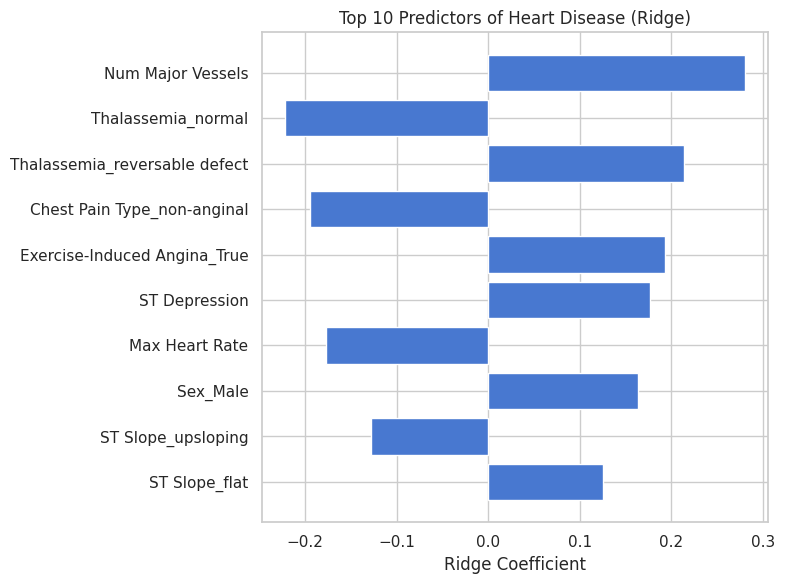

In [ ]:
top10 = coef_df_sorted.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Ridge Coefficient")
plt.title("Top 10 Predictors of Heart Disease (Ridge)")
plt.tight_layout()
plt.show()

## Attempted Polynomial Transformation

In [ ]:
trestbps_mean = cleveland_df["Resting Blood Pressure"].mean()
trestbps_centered = cleveland_df["Resting Blood Pressure"] - trestbps_mean
trestbps_sq = trestbps_centered ** 2

scaler_poly = StandardScaler()
trestbps_sq_scaled = scaler_poly.fit_transform(trestbps_sq.values.reshape(-1,1))

X_scaled_with_poly = np.hstack([X_scaled, trestbps_sq_scaled])

feature_names = list(X.columns) + ["Resting_BP_squared"]
X_vif = pd.DataFrame(X_scaled_with_poly, columns=feature_names)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

                            Feature       VIF
15               ST Slope_upsloping  5.935865
16               Thalassemia_normal  5.492508
14                    ST Slope_flat  4.877589
17    Thalassemia_reversable defect  4.801361
4                     ST Depression  1.872376
3                    Max Heart Rate  1.735720
8       Chest Pain Type_non-anginal  1.513568
7   Chest Pain Type_atypical angina  1.505939
0                               Age  1.502992
13     Exercise-Induced Angina_True  1.443674
1            Resting Blood Pressure  1.414384
5                 Num Major Vessels  1.377538
6                          Sex_Male  1.355310
18               Resting_BP_squared  1.255537
9    Chest Pain Type_typical angina  1.244705
2                       Cholesterol  1.150691
10         Fasting Blood Sugar_True  1.130009
11               Resting ECG_normal  1.121543
12     Resting ECG_st-t abnormality  1.081320


In [ ]:
poly_results = cv_logistic_baseline(X_scaled_with_poly, y, n_splits=5, random_state=42)

Fold 1: Train AUC=0.9313, Train Acc=0.8734 | Val AUC=0.9397, Val Acc=0.9000 | FitTime=0.0258s
Fold 2: Train AUC=0.9414, Train Acc=0.8734 | Val AUC=0.8616, Val Acc=0.8000 | FitTime=0.0492s
Fold 3: Train AUC=0.9545, Train Acc=0.9034 | Val AUC=0.8322, Val Acc=0.7627 | FitTime=0.0612s
Fold 4: Train AUC=0.9427, Train Acc=0.8487 | Val AUC=0.8611, Val Acc=0.8136 | FitTime=0.0721s
Fold 5: Train AUC=0.9310, Train Acc=0.8655 | Val AUC=0.9352, Val Acc=0.8136 | FitTime=0.0778s

=== 5-Fold CV Summary (Baseline Logistic) ===
Train AUC: 0.9402 ± 0.0097
Val AUC:   0.8860 ± 0.0485
Train Acc: 0.8729 ± 0.0198
Val Acc:   0.8180 ± 0.0504
Fit time:  0.0572s ± 0.0207s
